# Day 5: Ribosomes

Provide a CSV file containing the data, and a platemap. This function returns both the data with the plate map mapped to it, and the platemap by itself, which is useful for certain tasks.

In [1]:
!pip install nucleus-cdk==0.5.0rc2 | tail -n2

In [2]:
# from cdk.analysis.cytosol import platereader as pr
import platereader as pr
import warnings

# Ignore warnings
warnings.filterwarnings('ignore')

# Initialize plotting
pr.plot_setup()

In [3]:
platemap_path = '../1-design/20250516-ribosomes.tsv'
data_path = '../2-data/20250516-cytation3-pure-timecourse-gfp-trna-ribo-2-lower-gain-biotek-cdk.txt'

data, platemap = pr.load_platereader_data(data_path, platemap_path)

# Basic Plots

## Kinetics 
Kinetic time traces of every well on the plate

In [4]:
data_gain1 = data[data.Read == 'GFP-Filter-G50-485/20,528/20']
data_gain2 = data[data.Read == 'GFP-MC-G80-485,528']

## Steady state
Bar graph of steady-state endpoint of each sample. Steady state is calculated as the maximum fluorescence value over a 3-sample rolling average on the data.

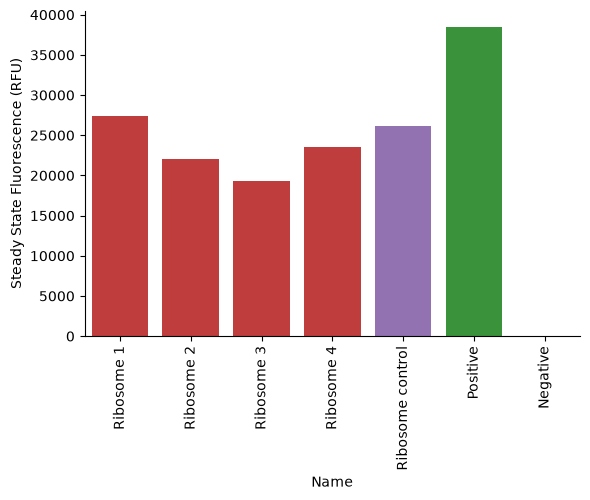

In [5]:
#| label: day5-ribosomes

replace_dict = {'Han&Sev Rib':'Ribosome 1',
                'Jake&Tyler Rib':'Ribosome 2',
                'Red1 Rib':'Ribosome 3',
                'Red2 Rib':'Ribosome 4',
                'Rib Control':'Ribosome control'}

custom_order = ['Ribosome 1', 
                'Ribosome 2',
                'Ribosome 3',
                'Ribosome 4',
                'Ribosome control',
                'Positive', 
                'Negative']

color_map = {'Ribosome 1': '#d62728',
             'Ribosome 2': '#d62728',
             'Ribosome 3': '#d62728',
             'Ribosome 4': '#d62728',
             'Ribosome control': '#9467bd',
             'Positive': '#2ca02c',
             'Negative': '#1f77b4'}

data_gain1['Name'] = data_gain1['Name'].replace(replace_dict)
pr.plot_steadystate(data_gain1, palette=color_map, order=custom_order);